# IMPORT

In [1]:
# 1. Standard library imports
import os

# 2. Third-party imports (Data Science, Visualization, Utilities)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from prettytable import PrettyTable
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GroupShuffleSplit
from tqdm import tqdm
import librosa
import cv2

# 3. Deep Learning imports (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models

# DATA

In [2]:
DATASET_FOLDER = "dataset/cremad/AudioWAV"

data = []

EMOTION_MAP = {
    "ANG": "Anger",
    "DIS": "Disgust",
    "FEA": "Fear",
    "HAP": "Happy",
    "NEU": "Neutral",
    "SAD": "Sad",
}

for file in os.listdir(DATASET_FOLDER):
    filename, _ = os.path.splitext(file)

    parts = filename.split("_")

    # Speaker
    speaker = parts[0]

    # Path
    path = f"{DATASET_FOLDER}/{file}"

    # Emotion
    emotion_code = parts[2]
    emotion = EMOTION_MAP.get(emotion_code, "Unknown")

    data.append([speaker, path, emotion])

df = pd.DataFrame(data, columns=["speaker", "path", "emotion"])

os.makedirs("CSVs", exist_ok=True)
df.to_csv("CSVs/dataset.csv", index=False)

df.head()

,speaker,path,emotion
0,1001,dataset/cremad/AudioWAV/1001_DFA_ANG_XX.wav,Anger
1,1001,dataset/cremad/AudioWAV/1001_DFA_DIS_XX.wav,Disgust
2,1001,dataset/cremad/AudioWAV/1001_DFA_FEA_XX.wav,Fear
3,1001,dataset/cremad/AudioWAV/1001_DFA_HAP_XX.wav,Happy
4,1001,dataset/cremad/AudioWAV/1001_DFA_NEU_XX.wav,Neutral


In [3]:
TRAIN_RATIO = 0.7
TEMP_RATIO = 1 - TRAIN_RATIO
RANDOM_STATE = 42

dataset = pd.read_csv("CSVs/dataset.csv")

assert len(dataset) > 0, "dataset empty"

# Split 1: train - temp (val + test)
gss_train = GroupShuffleSplit(
    test_size=TEMP_RATIO,
    n_splits=1,
    random_state=RANDOM_STATE
)

train_idx, temp_idx = next(
    gss_train.split(
        dataset,
        groups=dataset["speaker"]
    )
)

# Split 2: val - test
temp_subset = dataset.iloc[temp_idx]

gss_val = GroupShuffleSplit(
    test_size=0.5,
    n_splits=1,
    random_state=RANDOM_STATE
)

val_idx, test_idx = next(
    gss_val.split(
        temp_subset,
        groups=temp_subset["speaker"]
    )
)

train_df = dataset.iloc[train_idx].reset_index(drop=True)
val_df = temp_subset.iloc[val_idx].reset_index(drop=True)
test_df = temp_subset.iloc[test_idx].reset_index(drop=True)

print(
    f"Train : {len(train_df):>5} samples ({len(train_df) / len(dataset) * 100:.1f}%) - speaker: {len(set(train_df['speaker']))}")
print(
    f"Val   : {len(val_df):>5} samples ({len(val_df) / len(dataset) * 100:.1f}%) - speaker: {len(set(val_df['speaker']))}")
print(
    f"Test  : {len(test_df):>5} samples ({len(test_df) / len(dataset) * 100:.1f}%) - speaker: {len(set(test_df['speaker']))}")


def create_csv(df, path):
    df.to_csv(path, index=False)


os.makedirs("CSVs", exist_ok=True)

create_csv(train_df, "CSVs/train.csv")
create_csv(val_df, "CSVs/val.csv")
create_csv(test_df, "CSVs/test.csv")

# Check for actor overlap (LEAK)

train_actors = set(train_df["speaker"])
val_actors = set(val_df["speaker"])
test_actors = set(test_df["speaker"])

assert train_actors.isdisjoint(val_actors), "LEAK: actor appears in both train and val!"
assert train_actors.isdisjoint(test_actors), "LEAK: actor appears in both train and test!"
assert val_actors.isdisjoint(test_actors), "LEAK: actor appears in both val and test!"
print("\nNo actor overlap between splits. Data leakage check passed!")

Train :  5152 samples (69.2%) - speaker: 63
Val   :  1142 samples (15.3%) - speaker: 14
Test  :  1148 samples (15.4%) - speaker: 14

No actor overlap between splits. Data leakage check passed!


# PREPROCESS

## Helper function

In [4]:
# CONFIG

SAMPLE_RATE = 22050  # Hz – tần số lấy mẫu chuẩn
TARGET_SECONDS = 3.0  # giây – độ dài cố định sau pad/trim
N_MELS = 128  # số mel filter bank
N_FFT = 2048  # cửa sổ FFT
HOP_LENGTH = 512  # bước nhảy giữa các frame
F_MAX = 8000  # tần số mel tối đa (Hz)

# number of sample for TARGET_SECONDS (66150 samples)
TARGET_LENGTH = int(SAMPLE_RATE * TARGET_SECONDS)


def load_audio(path):
    audio, _ = librosa.load(path, sr=SAMPLE_RATE)

    # convert to float32 for consistency and to save memory than float64
    audio = audio.astype(np.float32)

    return audio


def pad_trim(audio):
    current_length = len(audio)

    if current_length > TARGET_LENGTH:  # If audio is too long, trim it
        audio_fixed = audio[:TARGET_LENGTH]


    elif current_length < TARGET_LENGTH:  # If audio is too short, pad it with zeros
        num_missing = TARGET_LENGTH - current_length
        padding = np.zeros(num_missing, dtype=np.float32)
        audio_fixed = np.concatenate((audio, padding))

    else:  # If audio is already the right length, keep it as is
        audio_fixed = audio

    return audio_fixed


def extract_features(audio):
    # Create mel spectrogram
    mel_spectrogram = librosa.feature.melspectrogram(
        y=audio,
        sr=SAMPLE_RATE,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        fmax=F_MAX
    )

    # Convert to log scale (dB) and compute deltas
    log_mel = librosa.power_to_db(mel_spectrogram, ref=np.max)
    delta = librosa.feature.delta(log_mel)
    delta2 = librosa.feature.delta(log_mel, order=2)

    # Stack log-mel, delta, and delta-delta to create a 3-channel feature map
    feature = np.stack([log_mel, delta, delta2], axis=0)
    feature = feature.astype(np.float32)

    return feature


def save_npy(feature, save_path):
    save_dir = os.path.dirname(save_path)
    if save_dir != "":
        os.makedirs(save_dir, exist_ok=True)

    np.save(save_path, feature)

# Map emotion string → int (dùng sorted để thứ tự nhất quán)
LABEL_MAP = {
    "Anger":   0,
    "Disgust": 1,
    "Fear":    2,
    "Happy":   3,
    "Neutral": 4,
    "Sad":     5,
}


## Process function


In [5]:
def preprocess_one_audio(audio_path, save_path):
    audio = load_audio(audio_path)
    audio_fixed = pad_trim(audio)
    feature = extract_features(audio_fixed)
    save_npy(feature, save_path)


def preprocess_dataset(df, save_root):
    os.makedirs(save_root, exist_ok=True)

    metadata = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Preprocessing"):
        audio_path = row["path"]

        npy_name = (os.path.splitext(os.path.basename(audio_path))[0] + ".npy")

        save_path = f"{save_root}/{npy_name}"

        try:
            if not os.path.exists(save_path):
                preprocess_one_audio(audio_path, save_path)

            metadata.append({
                "audio_path": audio_path,
                "feat_path": save_path,
                "emotion": row["emotion"],
                "label": LABEL_MAP[row["emotion"]],
                "speaker": row["speaker"]
            })

        except Exception as e:
            print(f"Error processing {audio_path}: {e}")

    metadata_df = pd.DataFrame(metadata)

    return metadata_df

## Run

In [6]:
train = pd.read_csv("CSVs/train.csv")
val = pd.read_csv("CSVs/val.csv")
test = pd.read_csv("CSVs/test.csv")

train_npy = preprocess_dataset(
    train,
    "features/train"
)

val_npy = preprocess_dataset(
    val,
    "features/val"
)

test_npy = preprocess_dataset(
    test,
    "features/test"
)

create_csv(train_npy, "CSVs/train_npy.csv")
create_csv(val_npy, "CSVs/val_npy.csv")
create_csv(test_npy, "CSVs/test_npy.csv")

Preprocessing:   0%|          | 0/5152 [00:00<?, ?it/s]

Preprocessing: 100%|██████████| 1148/1148 [00:00<00:00, 1883.23it/s]


# AUGMENT

## Helper function

In [7]:
# Config

TIME_MASK_MAX_WIDTH = 40  # che tối đa 40 frame thời gian
FREQ_MASK_MAX_WIDTH = 20  # che tối đa 20 bin tần số
NUM_TIME_MASKS = 2  # số lần che theo thời gian
NUM_FREQ_MASKS = 2  # số lần che theo tần số


def apply_time_mask(feature, max_width, num_masks):
    num_frames = feature.shape[2]

    for _ in range(num_masks):
        # randomly select a time segment to mask
        # start range is [0, num_frames - max_width] to ensure we have enough frames to mask
        # end range is [start, start + max_width] to ensure the mask width does not exceed max_width
        # feature shape is (channels, n_mels, time_frames)
        mask_width = np.random.randint(0, max_width + 1)
        start = np.random.randint(0, num_frames - mask_width + 1)
        end = start + mask_width

        feature[:, :, start:end] = 0.0

    return feature


def apply_freq_mask(feature, max_width, num_masks):
    num_bins = feature.shape[1]

    for _ in range(num_masks):
        # randomly select a frequency band to mask
        # start range is [0, num_bins - max_width] to ensure we have enough bins to mask
        # end range is [start, start + max_width] to ensure the mask width does not exceed max_width
        # feature shape is (channels, n_mels, time_frames)
        mask_width = np.random.randint(0, max_width + 1)
        start = np.random.randint(0, num_bins - mask_width + 1)
        end = start + mask_width

        feature[:, start:end, :] = 0.0

    return feature


def apply_specaugment(feature):
    feature = feature.copy()

    feature = apply_time_mask(feature, TIME_MASK_MAX_WIDTH, NUM_TIME_MASKS)
    feature = apply_freq_mask(feature, FREQ_MASK_MAX_WIDTH, NUM_FREQ_MASKS)

    return feature

## DATASET CLASS

In [8]:
class SERDataset(Dataset):
    def __init__(self, df, is_train, target_size=(128, 128)):
        self.df = df
        self.is_train = is_train
        self.target_size = target_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        # Load pre-extracted feature
        row = self.df.iloc[index]

        feature = np.load(
            row["feat_path"]
        )

        label = row["label"]

        if self.is_train:
            feature = apply_specaugment(feature)

        feature = resize_feature(feature, self.target_size)
        feature = normalize(feature)

        # Convert to PyTorch tensor
        feature_tensor = torch.tensor(feature, dtype=torch.float32)
        label_tensor = torch.tensor(label, dtype=torch.long)

        return feature_tensor, label_tensor


def resize_feature(feature, target_size):
    target_height, target_width = target_size
    channels = []

    for channel_index in range(feature.shape[0]):
        one_channel = feature[channel_index]  # shape (n_mels, time_frames)

        # Resize to target size using OpenCV (interpolation can be adjusted if needed)
        resized_channel = cv2.resize(
            one_channel,
            (target_width, target_height),
            interpolation=cv2.INTER_LINEAR
        )
        channels.append(resized_channel)

    # Stack all channels back together => shape (channels, target_height, target_width)
    resized = np.stack(channels, axis=0)
    return resized


def normalize(feature):
    imagenet_mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    imagenet_std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    feature_min = feature.min()
    feature_max = feature.max()

    # Normalize to [0, 1]
    if feature_max - feature_min > 1e-6:
        feature = (feature - feature_min) / (feature_max - feature_min)
    else:
        feature = np.zeros_like(feature)

    # Normalize to zero mean and unit variance using ImageNet statistics
    for channel_index in range(3):
        feature[channel_index] = (feature[channel_index] - imagenet_mean[channel_index]) / imagenet_std[channel_index]

    return feature

## Run

In [9]:
TRAIN_NPY = pd.read_csv("CSVs/train_npy.csv")
VAL_NPY = pd.read_csv("CSVs/val_npy.csv")
TEST_NPY = pd.read_csv("CSVs/test_npy.csv")

train_dataset = SERDataset(
    TRAIN_NPY,
    is_train=True
)

val_dataset = SERDataset(
    VAL_NPY,
    is_train=False
)

test_dataset = SERDataset(
    TEST_NPY,
    is_train=False
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# TRAIN

## Config

In [10]:
NUM_CLASSES     = 6      # CREMA-D: ANG, DIS, FEA, HAP, NEU, SAD
NUM_EPOCHS      = 30
BATCH_SIZE      = 32
LABEL_SMOOTHING = 0.1
WEIGHT_DECAY    = 1e-4
PATIENCE        = 7      # early stopping: dừng nếu val_loss không giảm sau 7 epoch

# Learning rate theo từng giai đoạn fine-tune
LR_HEAD_FROZEN   = 1e-3   # epoch 1–5:  chỉ train FC head
LR_BACKBONE_MID  = 1e-4   # epoch 6–15: unfreeze layer cuối backbone
LR_HEAD_MID      = 1e-3
LR_BACKBONE_FULL = 1e-5   # epoch 16–30: unfreeze toàn bộ
LR_HEAD_FULL     = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(DEVICE)

cuda


## MODEL

In [11]:
def build_fc_head(num_input_features, num_classes):
    head = nn.Sequential(
        nn.Linear(num_input_features, 512),
        nn.BatchNorm1d(512),
        nn.ReLU(),
        nn.Dropout(p=0.5),

        nn.Linear(512, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(p=0.3),

        nn.Linear(256, num_classes),
    )
    return head

### resnet

In [ ]:
class BuildResnet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        for param in self.model.parameters():
            param.requires_grad = False
            
        for param in self.model.layer4.parameters():
            param.requires_grad = True
                
        self.model.fc = build_fc_head(self.model.fc.in_features, num_classes) # type: ignore

    def forward(self, x):
        return self.model(x)

### densenet

In [13]:
class BuildDenseNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

        # Freeze toàn bộ backbone
        for param in self.model.parameters():
            param.requires_grad = False

        # Thay classifier bằng custom head dùng chung
        self.model.classifier = build_fc_head(self.model.classifier.in_features, num_classes) # type: ignore

    def forward(self, x):
        return self.model(x)


### vgg

In [14]:
class BuildVGG16(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

        # Freeze toàn bộ backbone
        for param in self.model.parameters():
            param.requires_grad = False

        # model.classifier[0].in_features = 25088 (AdaptiveAvgPool đảm bảo luôn đúng)
        self.model.classifier = build_fc_head(self.model.classifier[0].in_features, num_classes)

    def forward(self, x):
        return self.model(x)


### build all

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = len(EMOTION_MAP)

def build_all(num_classes=NUM_CLASSES):
    resnet   = BuildResnet(num_classes).to(device)
    densenet = BuildDenseNet(num_classes).to(device)
    vgg      = BuildVGG16(num_classes).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    optimizers = {
        "ResNet18": optim.AdamW([
            {"params": resnet.model.layer4.parameters(), "lr": 1e-5},
            {"params": resnet.model.fc.parameters(), "lr": 5e-5},
        ], weight_decay=5e-4
                                ),
        "DenseNet121": optim.AdamW(
            densenet.model.classifier.parameters(),
            lr=LR_HEAD_FROZEN, weight_decay=WEIGHT_DECAY,
        ),
        "VGG16": optim.AdamW(
            vgg.model.classifier.parameters(),
            lr=LR_HEAD_FROZEN, weight_decay=WEIGHT_DECAY,
        ),
    }

    schedulers = {
        name: optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="min", factor=0.5, patience=5
        )
        for name, opt in optimizers.items()
    }

    models_dict = {"ResNet18": resnet, "DenseNet121": densenet, "VGG16": vgg}

    # Summary
    print(f"Device: {DEVICE}\n")
    for name, model in models_dict.items():
        total     = sum(p.numel() for p in model.parameters())
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"{name:<12} trainable: {trainable:>9,} / {total:>9,} ({trainable/total*100:.1f}%)")

    return models_dict, optimizers, schedulers, criterion


models_dict, optimizers, schedulers, criterion = build_all()



Device: cuda

ResNet18     trainable: 8,790,790 / 11,573,574 (76.0%)
DenseNet121  trainable:   659,206 / 7,613,062 (8.7%)
VGG16        trainable: 12,979,974 / 27,694,662 (46.9%)


## TRAIN & VAL

In [16]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total = 0.0, 0
    all_labels, all_preds = [], []

    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total += images.size(0)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())

    return total_loss / total, all_labels, all_preds

def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, total = 0.0, 0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            total += images.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())

    return total_loss / total, all_labels, all_preds

def compute_metrics(labels, preds):
    return {
        "acc":       accuracy_score(labels, preds),
        "f1":        f1_score(labels, preds, average="weighted"),
        "recall":    recall_score(labels, preds, average="weighted", zero_division=0),
        "precision": precision_score(labels, preds, average="weighted", zero_division=0),
    }
    
def log_epoch(name, epoch, epochs, optimizer, train_loss, train_m, val_loss, val_m):
    lr_str = " | ".join(f"g{i}:{pg['lr']:.1e}" for i, pg in enumerate(optimizer.param_groups))

    table = PrettyTable()
    table.title       = f"[{name}] Epoch {epoch}/{epochs}  ({lr_str})"
    table.field_names = ["Split", "Loss", "Acc", "F1", "Recall", "Precision"]
    table.align       = "r"
    table.float_format = ".4"
    table.add_row(["Train", train_loss, train_m["acc"], train_m["f1"], train_m["recall"], train_m["precision"]])
    table.add_row(["Val",   val_loss,   val_m["acc"],   val_m["f1"],   val_m["recall"],   val_m["precision"]])
    print(table)
    
def train_model(model, optimizer, scheduler, criterion,
                train_loader, val_loader,
                name, epochs=30, patience=7):

    save_path = f"{name}.pth"
    history   = {"train_loss": [], "train_acc": [], "train_f1": [],
                  "val_loss":   [], "val_acc":   [], "val_f1":   []}

    best_val_loss = float("inf")
    best_epoch    = 0
    no_improve    = 0

    for epoch in range(1, epochs + 1):
        train_loss, train_labels, train_preds = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss,   val_labels,   val_preds   = eval_one_epoch(model, val_loader, criterion, device)

        train_m = compute_metrics(train_labels, train_preds)
        val_m   = compute_metrics(val_labels,   val_preds)

        scheduler.step(val_loss)
        log_epoch(name, epoch, epochs, optimizer, train_loss, train_m, val_loss, val_m)

        for k, v in [("train_loss", train_loss), ("train_acc", train_m["acc"]), ("train_f1", train_m["f1"]),
                     ("val_loss",   val_loss),    ("val_acc",   val_m["acc"]),   ("val_f1",   val_m["f1"])]:
            history[k].append(v)

        # Early stopping & checkpoint
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch    = epoch
            no_improve    = 0
            torch.save(model.state_dict(), save_path)
            print(f"  --> Saved (val_loss={best_val_loss:.4f})")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    print(f"\n[{name}] Done. Best epoch: {best_epoch} | Best val_loss: {best_val_loss:.4f}")
    return history

### resnet

In [17]:
history_resnet = train_model(
    models_dict["ResNet18"],
    optimizers["ResNet18"],
    schedulers["ResNet18"],
    criterion,
    train_loader, 
    val_loader,  
    name="ResNet18"
)

+-------------------------------------------------------+
|    [ResNet18] Epoch 1/30  (g0:1.0e-05 | g1:5.0e-05)   |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.8398 | 0.1912 | 0.1828 | 0.1912 |    0.2000 |
|   Val | 1.7827 | 0.2259 | 0.1803 | 0.2259 |    0.2456 |
+-------+--------+--------+--------+--------+-----------+
  --> Saved (val_loss=1.7827)


+-------------------------------------------------------+
|    [ResNet18] Epoch 2/30  (g0:1.0e-05 | g1:5.0e-05)   |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.7498 | 0.2587 | 0.2522 | 0.2587 |    0.2509 |
|   Val | 1.7299 | 0.2863 | 0.2439 | 0.2863 |    0.2935 |
+-------+--------+--------+--------+--------+-----------+
  --> Saved (val_loss=1.7299)


+-------------------------------------------------------+
|    [ResNet18] Epoch 3/30  (g0:1.0e-05 | g1:5.0e-05)   |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.7134 | 0.2859 | 0.2703 | 0.2859 |    0.2669 |
|   Val | 1.6868 | 0.3091 | 0.2597 | 0.3091 |    0.3556 |
+-------+--------+--------+--------+--------+-----------+
  --> Saved (val_loss=1.6868)


+-------------------------------------------------------+
|    [ResNet18] Epoch 4/30  (g0:1.0e-05 | g1:5.0e-05)   |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.6730 | 0.3094 | 0.2898 | 0.3094 |    0.2870 |
|   Val | 1.6496 | 0.3380 | 0.2879 | 0.3380 |    0.3334 |
+-------+--------+--------+--------+--------+-----------+
  --> Saved (val_loss=1.6496)


+-------------------------------------------------------+
|    [ResNet18] Epoch 5/30  (g0:1.0e-05 | g1:5.0e-05)   |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.6530 | 0.3141 | 0.2966 | 0.3141 |    0.2926 |
|   Val | 1.6351 | 0.3485 | 0.3070 | 0.3485 |    0.3609 |
+-------+--------+--------+--------+--------+-----------+
  --> Saved (val_loss=1.6351)


...

+-------------------------------------------------------+
|   [ResNet18] Epoch 26/30  (g0:1.0e-05 | g1:5.0e-05)   |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.5322 | 0.4026 | 0.3892 | 0.4026 |    0.3879 |
|   Val | 1.4969 | 0.4212 | 0.3852 | 0.4212 |    0.4209 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|   [ResNet18] Epoch 27/30  (g0:1.0e-05 | g1:5.0e-05)   |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.5143 | 0.4163 | 0.4021 | 0.4163 |    0.4031 |
|   Val | 1.4889 | 0.4361 | 0.4141 | 0.4361 |    0.4309 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|   [ResNet18] Epoch 28/30  (g0:1.0e-05 | g1:5.0e-05)   |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.5242 | 0.4163 | 0.4046 | 0.4163 |    0.4068 |
|   Val | 1.4944 | 0.4291 | 0.3970 | 0.4291 |    0.4263 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|   [ResNet18] Epoch 29/30  (g0:1.0e-05 | g1:5.0e-05)   |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.5241 | 0.4193 | 0.4067 | 0.4193 |    0.4076 |
|   Val | 1.4709 | 0.4483 | 0.4218 | 0.4483 |    0.4414 |
+-------+--------+--------+--------+--------+-----------+
  --> Saved (val_loss=1.4709)


+-------------------------------------------------------+
|   [ResNet18] Epoch 30/30  (g0:1.0e-05 | g1:5.0e-05)   |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.5162 | 0.4090 | 0.3970 | 0.4090 |    0.3976 |
|   Val | 1.4761 | 0.4448 | 0.4254 | 0.4448 |    0.4326 |
+-------+--------+--------+--------+--------+-----------+

[ResNet18] Done. Best epoch: 29 | Best val_loss: 1.4709


### densenet

In [18]:
history_densenet = train_model(
    models_dict["DenseNet121"], 
    optimizers["DenseNet121"],
    schedulers["DenseNet121"], 
    criterion,
    train_loader, 
    val_loader,  
    name="DenseNet121"
)

+-------------------------------------------------------+
|         [DenseNet121] Epoch 1/30  (g0:1.0e-03)        |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.7634 | 0.2494 | 0.2399 | 0.2494 |    0.2359 |
|   Val | 1.6061 | 0.3704 | 0.3436 | 0.3704 |    0.3677 |
+-------+--------+--------+--------+--------+-----------+
  --> Saved (val_loss=1.6061)


+-------------------------------------------------------+
|         [DenseNet121] Epoch 2/30  (g0:1.0e-03)        |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.6855 | 0.3016 | 0.2874 | 0.3016 |    0.2843 |
|   Val | 1.6044 | 0.3835 | 0.3311 | 0.3835 |    0.3822 |
+-------+--------+--------+--------+--------+-----------+
  --> Saved (val_loss=1.6044)


+-------------------------------------------------------+
|         [DenseNet121] Epoch 3/30  (g0:1.0e-03)        |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.6562 | 0.3189 | 0.3003 | 0.3189 |    0.2979 |
|   Val | 1.6138 | 0.3398 | 0.2971 | 0.3398 |    0.3507 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|         [DenseNet121] Epoch 4/30  (g0:1.0e-03)        |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.6504 | 0.3243 | 0.3065 | 0.3243 |    0.3044 |
|   Val | 1.6034 | 0.3546 | 0.3069 | 0.3546 |    0.3451 |
+-------+--------+--------+--------+--------+-----------+
  --> Saved (val_loss=1.6034)


+-------------------------------------------------------+
|         [DenseNet121] Epoch 5/30  (g0:1.0e-03)        |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.6440 | 0.3292 | 0.3128 | 0.3292 |    0.3114 |
|   Val | 1.5903 | 0.3459 | 0.3077 | 0.3459 |    0.3479 |
+-------+--------+--------+--------+--------+-----------+
  --> Saved (val_loss=1.5903)


...

+-------------------------------------------------------+
|        [DenseNet121] Epoch 10/30  (g0:1.0e-03)        |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.6194 | 0.3517 | 0.3346 | 0.3517 |    0.3332 |
|   Val | 1.6058 | 0.3687 | 0.3226 | 0.3687 |    0.3462 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|        [DenseNet121] Epoch 11/30  (g0:1.0e-03)        |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.6114 | 0.3451 | 0.3286 | 0.3451 |    0.3278 |
|   Val | 1.5989 | 0.3757 | 0.3271 | 0.3757 |    0.3851 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|        [DenseNet121] Epoch 12/30  (g0:1.0e-03)        |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.6143 | 0.3502 | 0.3317 | 0.3502 |    0.3326 |
|   Val | 1.6257 | 0.3433 | 0.3037 | 0.3433 |    0.3642 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|        [DenseNet121] Epoch 13/30  (g0:5.0e-04)        |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.6220 | 0.3368 | 0.3219 | 0.3368 |    0.3196 |
|   Val | 1.5989 | 0.3573 | 0.3062 | 0.3573 |    0.3494 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|        [DenseNet121] Epoch 14/30  (g0:5.0e-04)        |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.6013 | 0.3502 | 0.3282 | 0.3502 |    0.3285 |
|   Val | 1.6414 | 0.3503 | 0.2992 | 0.3503 |    0.3640 |
+-------+--------+--------+--------+--------+-----------+
  Early stopping at epoch 14.

[DenseNet121] Done. Best epoch: 7 | Best val_loss: 1.5762


### vgg

In [19]:
history_vgg = train_model(
    models_dict["VGG16"],       
    optimizers["VGG16"],
    schedulers["VGG16"],       
    criterion,
    train_loader, 
    val_loader,  
    name="VGG16"
)

+-------------------------------------------------------+
|            [VGG16] Epoch 1/30  (g0:1.0e-03)           |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.7483 | 0.2690 | 0.2623 | 0.2690 |    0.2598 |
|   Val | 1.6276 | 0.3310 | 0.2638 | 0.3310 |    0.3273 |
+-------+--------+--------+--------+--------+-----------+
  --> Saved (val_loss=1.6276)


+-------------------------------------------------------+
|            [VGG16] Epoch 2/30  (g0:1.0e-03)           |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.6426 | 0.3309 | 0.3205 | 0.3309 |    0.3197 |
|   Val | 1.7659 | 0.3065 | 0.2600 | 0.3065 |    0.3858 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|            [VGG16] Epoch 3/30  (g0:1.0e-03)           |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.6285 | 0.3354 | 0.3216 | 0.3354 |    0.3198 |
|   Val | 1.6142 | 0.3503 | 0.3155 | 0.3503 |    0.3464 |
+-------+--------+--------+--------+--------+-----------+
  --> Saved (val_loss=1.6142)


+-------------------------------------------------------+
|            [VGG16] Epoch 4/30  (g0:1.0e-03)           |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.6053 | 0.3601 | 0.3437 | 0.3601 |    0.3417 |
|   Val | 1.5517 | 0.3905 | 0.3559 | 0.3905 |    0.4173 |
+-------+--------+--------+--------+--------+-----------+
  --> Saved (val_loss=1.5517)


+-------------------------------------------------------+
|            [VGG16] Epoch 5/30  (g0:1.0e-03)           |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.5924 | 0.3602 | 0.3455 | 0.3602 |    0.3438 |
|   Val | 1.5592 | 0.3844 | 0.3335 | 0.3844 |    0.4427 |
+-------+--------+--------+--------+--------+-----------+


...

+-------------------------------------------------------+
|           [VGG16] Epoch 22/30  (g0:1.0e-03)           |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.5480 | 0.3905 | 0.3787 | 0.3905 |    0.3803 |
|   Val | 1.4967 | 0.4194 | 0.3723 | 0.4194 |    0.4211 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|           [VGG16] Epoch 23/30  (g0:1.0e-03)           |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.5450 | 0.3913 | 0.3798 | 0.3913 |    0.3787 |
|   Val | 1.5047 | 0.4177 | 0.3820 | 0.4177 |    0.4326 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|           [VGG16] Epoch 24/30  (g0:1.0e-03)           |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.5544 | 0.3997 | 0.3866 | 0.3997 |    0.3866 |
|   Val | 1.5008 | 0.4335 | 0.3917 | 0.4335 |    0.4548 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|           [VGG16] Epoch 25/30  (g0:5.0e-04)           |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.5453 | 0.4008 | 0.3873 | 0.4008 |    0.3874 |
|   Val | 1.4979 | 0.4431 | 0.4271 | 0.4431 |    0.4367 |
+-------+--------+--------+--------+--------+-----------+


+-------------------------------------------------------+
|           [VGG16] Epoch 26/30  (g0:5.0e-04)           |
+-------+--------+--------+--------+--------+-----------+
| Split |   Loss |    Acc |     F1 | Recall | Precision |
+-------+--------+--------+--------+--------+-----------+
| Train | 1.5339 | 0.4146 | 0.4083 | 0.4146 |    0.4091 |
|   Val | 1.4905 | 0.4299 | 0.3907 | 0.4299 |    0.4430 |
+-------+--------+--------+--------+--------+-----------+
  Early stopping at epoch 26.

[VGG16] Done. Best epoch: 19 | Best val_loss: 1.4780


## Plot & test

In [20]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(21, 5))
    fig.suptitle(f"{model_name} — Training History", fontweight="bold")

    metrics = [
        ("Loss",     "train_loss", "val_loss"),
        ("Accuracy", "train_acc",  "val_acc"),
        ("F1 Score", "train_f1",   "val_f1"),
    ]

    for ax, (ylabel, train_key, val_key) in zip(axes, metrics):
        ax.plot(history[train_key], label=f"Train {ylabel}", marker="o", linewidth=2)
        ax.plot(history[val_key],   label=f"Val {ylabel}",   marker="o", linewidth=2)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.set_title(f"Train vs Val {ylabel}")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def evaluate_model(model, loader, model_name, emotions=None):
    model.eval()
    true_all, pred_all = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"Evaluating {model_name}", leave=False):
            images, labels = images.to(device), labels.to(device)
            preds = torch.argmax(model(images), dim=1)
            true_all.extend(labels.cpu().numpy())
            pred_all.extend(preds.cpu().numpy())

    # Classification report
    print(f"\n[{model_name}] Classification Report (Test):")
    emotion_names = emotions if emotions else [str(i) for i in range(NUM_CLASSES)]
    print(classification_report(true_all, pred_all,
                                target_names=emotion_names, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(true_all, pred_all)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=emotions, yticklabels=emotions) # type: ignore
    plt.title(f"{model_name} — Confusion Matrix (Test)")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return true_all, pred_all

## result

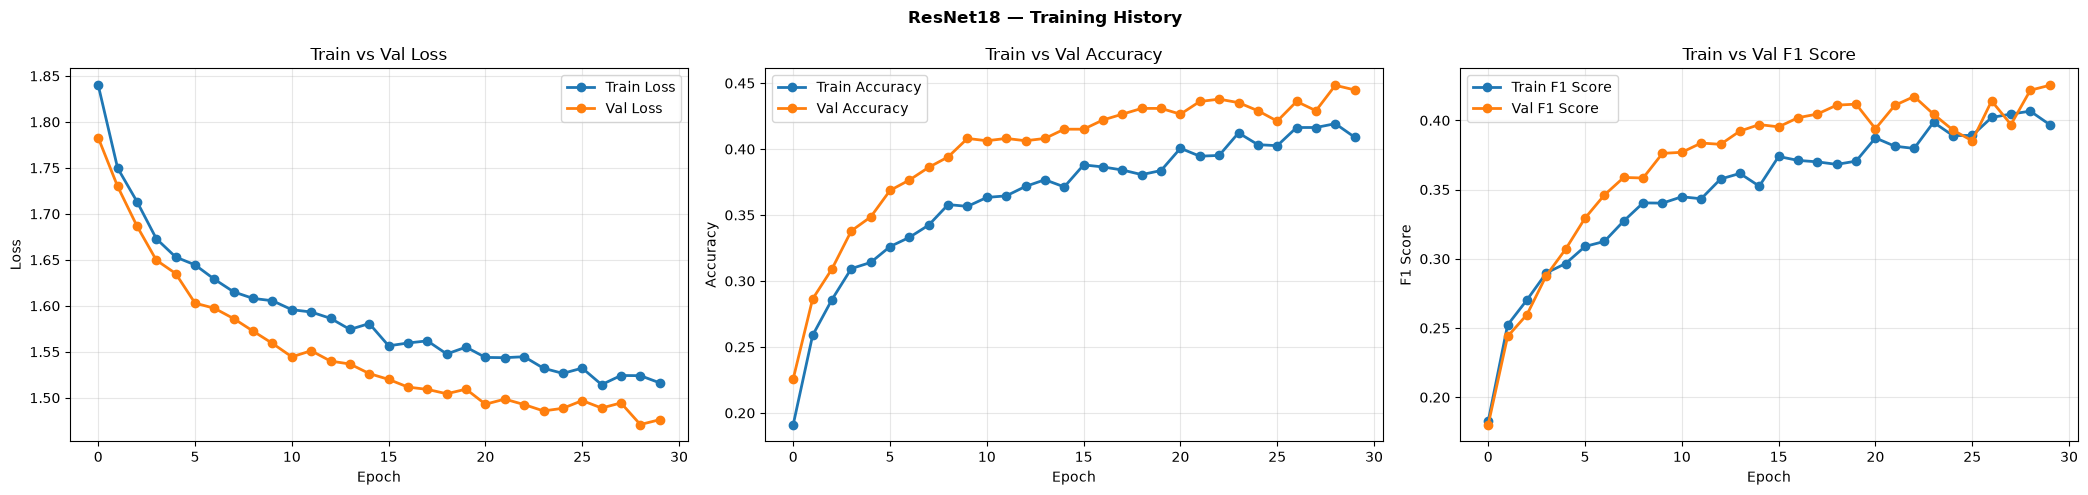


[ResNet18] Classification Report (Test):
              precision    recall  f1-score   support

       Anger       0.48      0.79      0.60       196
     Disgust       0.35      0.20      0.26       196
        Fear       0.42      0.16      0.23       196
       Happy       0.34      0.42      0.37       196
     Neutral       0.45      0.44      0.44       168
         Sad       0.47      0.56      0.51       196

    accuracy                           0.43      1148
   macro avg       0.42      0.43      0.40      1148
weighted avg       0.42      0.43      0.40      1148



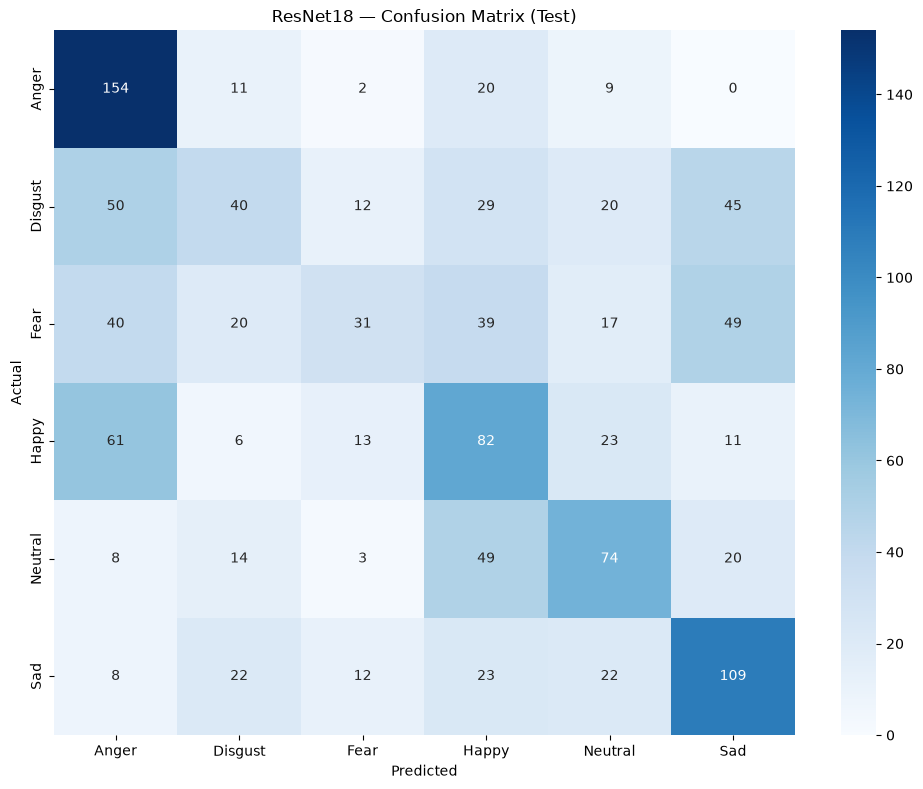

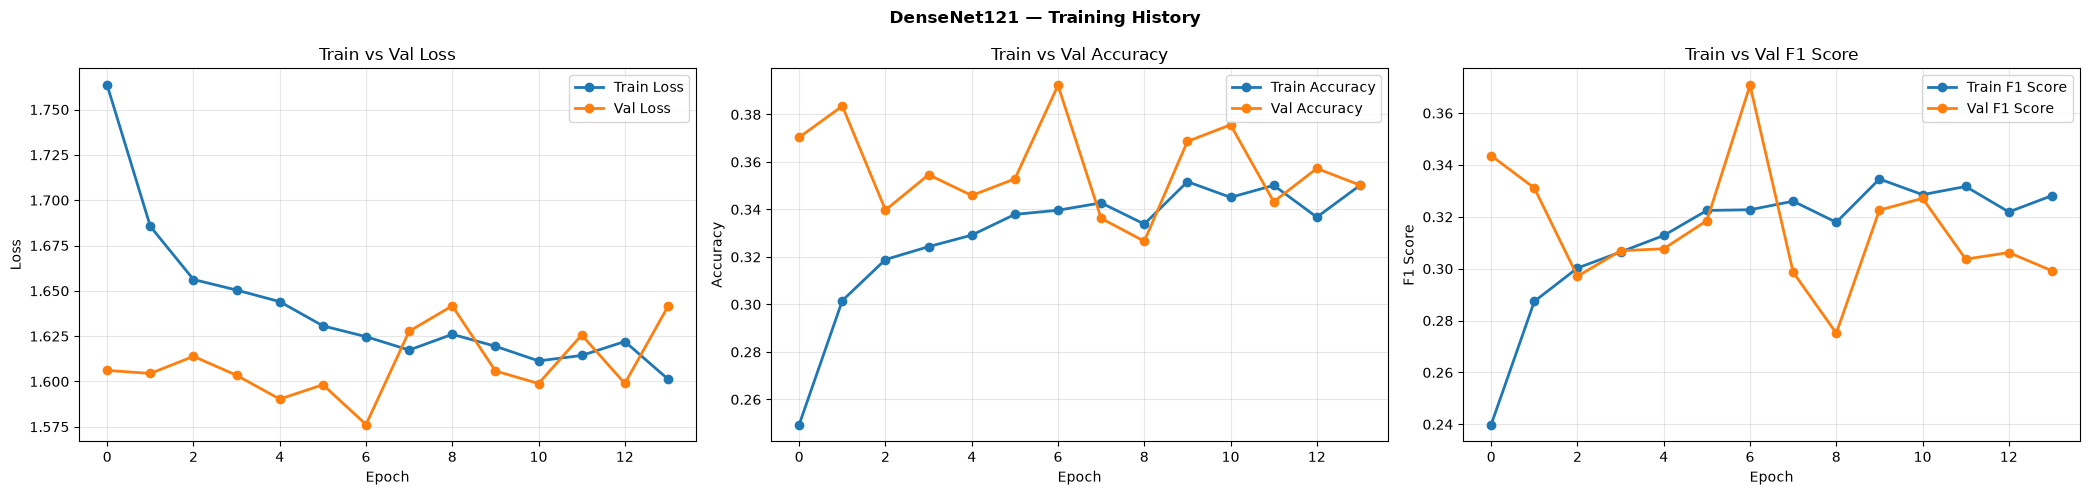


[DenseNet121] Classification Report (Test):
              precision    recall  f1-score   support

       Anger       0.43      0.70      0.53       196
     Disgust       0.27      0.31      0.29       196
        Fear       0.22      0.10      0.13       196
       Happy       0.26      0.21      0.23       196
     Neutral       0.35      0.35      0.35       168
         Sad       0.42      0.41      0.42       196

    accuracy                           0.35      1148
   macro avg       0.33      0.35      0.33      1148
weighted avg       0.32      0.35      0.33      1148



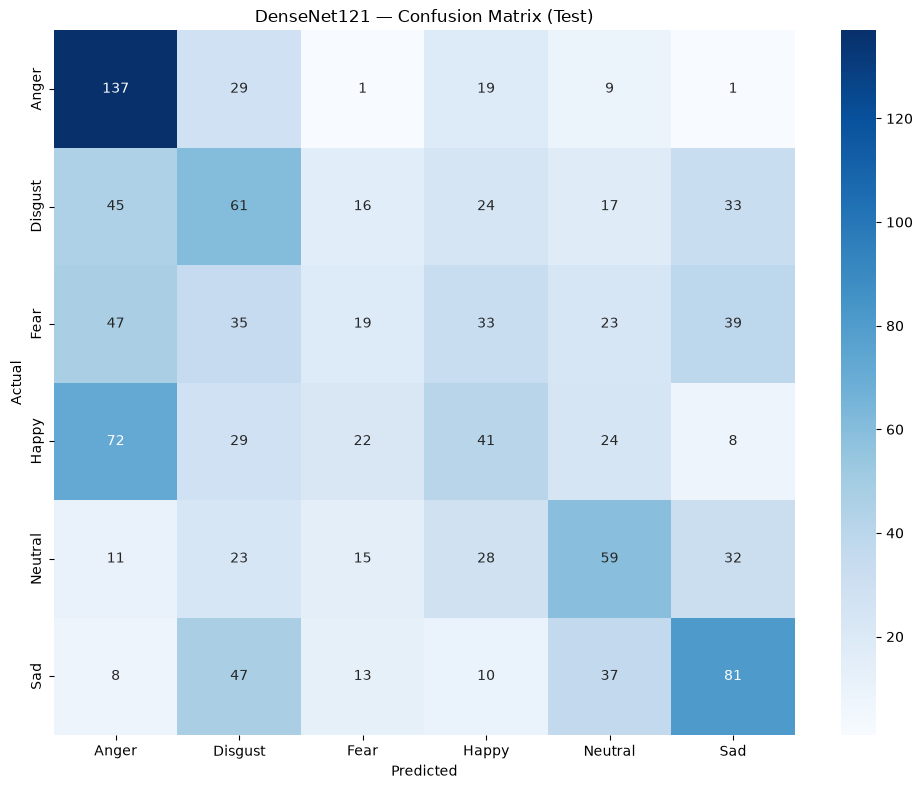

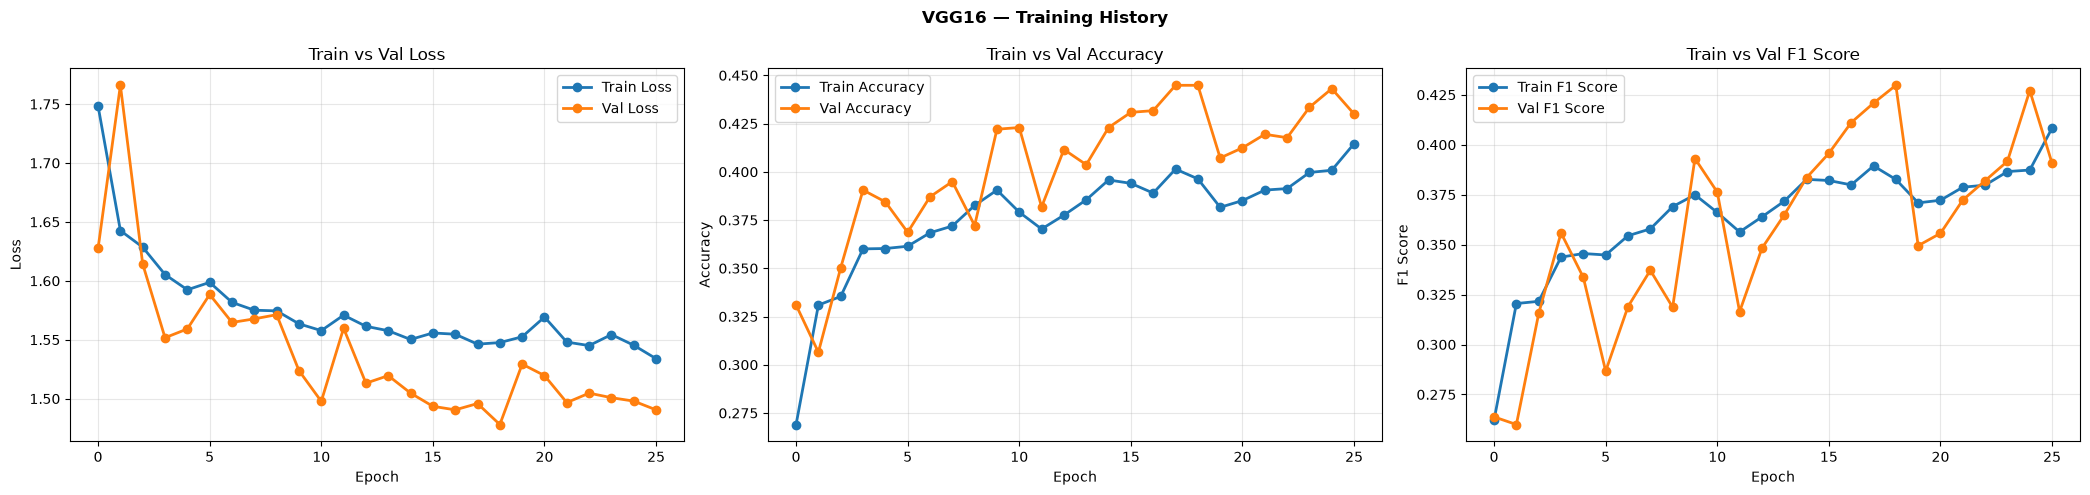


[VGG16] Classification Report (Test):
              precision    recall  f1-score   support

       Anger       0.50      0.68      0.58       196
     Disgust       0.39      0.19      0.25       196
        Fear       0.32      0.22      0.26       196
       Happy       0.35      0.52      0.42       196
     Neutral       0.47      0.41      0.44       168
         Sad       0.44      0.49      0.47       196

    accuracy                           0.42      1148
   macro avg       0.41      0.42      0.40      1148
weighted avg       0.41      0.42      0.40      1148



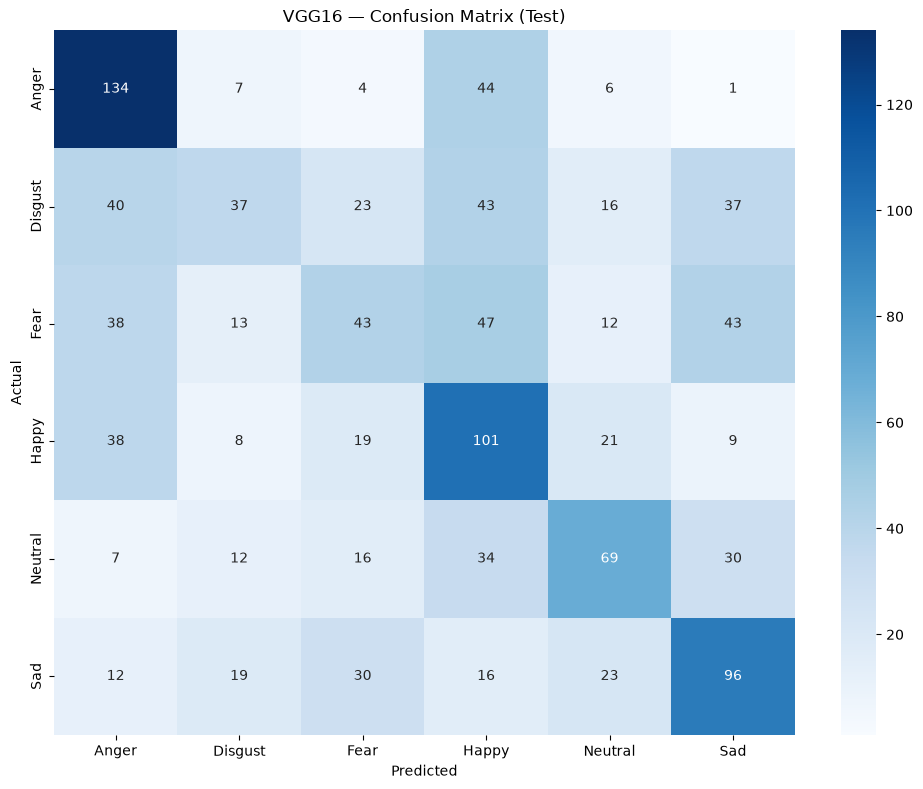

In [21]:
histories = {
    "ResNet18":    history_resnet,
    "DenseNet121": history_densenet,
    "VGG16":       history_vgg,
}

for name, model in models_dict.items():
    plot_history(histories[name], name)
    evaluate_model(model, test_loader, name, emotions=list(EMOTION_MAP.values()))
